# Data Wrangling with Pandas


Data structures: __Series__ and __DataFrame__.

### Import pasdas module and additional modules

In [2]:
import pandas as pd
import numpy as np

___

### Evaluating Duplicate Values

There are often duplicate values in a series. <br>
Then you may need to have more information about the samples, including __existence of any duplicates__ and whether a certain value is present in the series.

In [3]:
# There are duplicated values in the Series
serd = pd.Series([1,0,2,1,2,3], index=['white', 'white', 'blue', 'green', 'green', 'yellow'])
serd

white     1
white     0
blue      2
green     1
green     2
yellow    3
dtype: int64

To know all the values contained in the series, excluding duplicates, you can use the __unique()__ function. <br>
The return value is an array containing the unique values in the series, although not necessarily in order.

In [4]:
#Find an array containing the unique values in the series
serd.unique()

array([1, 0, 2, 3])

In [5]:
# value_count() is similar to unique() but also calculates the occurrences within a series
serd.value_counts()

1    2
2    2
0    1
3    1
Name: count, dtype: int64

In [6]:
#How to create Series with only unique index?
serd_value = serd.unique()
uniq_index = serd.index.unique()
print(uniq_index)
unique_serd = pd.Series(serd_value, index = uniq_index)
print(unique_serd)

Index(['white', 'blue', 'green', 'yellow'], dtype='object')
white     1
blue      0
green     2
yellow    3
dtype: int64


You can evaluate the membership of a Series data against the list you define with the __isin()__ function.
This function tells you if the values are contained in the data structure. Boolean values that are
returned can be very useful when filtering data in a series or in a column of a dataframe.

In [7]:
print(serd)
serd.isin([0,3])

white     1
white     0
blue      2
green     1
green     2
yellow    3
dtype: int64


white     False
white      True
blue      False
green     False
green     False
yellow     True
dtype: bool

In [8]:
serd[serd.isin([0,3])]

white     0
yellow    3
dtype: int64

#### The __isna()__ and __notna()__ functions are very useful to identify the indexes without a value.

### - Data Cleansing
This specific value __NaN (Not a Number)__ is used in pandas data structures to indicate the presence of __an empty field__ or something that’s __not definable numerically__. These data are often generated when extracting data from a questionable source or when the source is missing data. The NaN values can also be generated in special cases, such as calculations of logarithms of negative values, or exceptions during execution of some calculation or function.<br>

These NaN values are a problem and __must be managed__ in some way,especially during data analysis.

Filtering Out NaN Values

You eliminated all the NaN values by using __dropna() function__

The __isna()__ and __notna()__ functions are very useful to identify the indexes without a value.

In [9]:
import pandas as pd
import numpy as np
#You can enter np.nan or None wherever you want to define a missing value.
s2 = pd.Series([5, -3, np.nan, 14])
print(s2)


0     5.0
1    -3.0
2     NaN
3    14.0
dtype: float64


In [10]:
s2[0] = None
s2

0     NaN
1    -3.0
2     NaN
3    14.0
dtype: float64

In [11]:
#Boolean data type will be converted to object
pd.Series([True, False], dtype=np.bool_).reindex([0, 1, 2])

0     True
1    False
2      NaN
dtype: object

In [12]:
#NAT for NumPy np.datetime64, np.timedelta64
pd.Series([1, 2], dtype=np.dtype("timedelta64[ns]")).reindex([0, 1, 2])

0   0 days 00:00:00.000000001
1   0 days 00:00:00.000000002
2                         NaT
dtype: timedelta64[ns]

In [13]:
#The isna() function returns True at NaN values in the series
print(s2.isna())
print(s2.isna().sum())

0     True
1    False
2     True
3    False
dtype: bool
2


In [14]:
#notna() function returns True if they are not NaN.
s2.notna()

0    False
1     True
2    False
3     True
dtype: bool

In [15]:
#These functions are often placed inside filters to make a condition.
snn = s2[s2.notna()]
print("filter notna()")
print(snn)

print("-"*10)
print("filter isna()")
sn = s2[s2.isna()]
print(sn)

filter notna()
1    -3.0
3    14.0
dtype: float64
----------
filter isna()
0   NaN
2   NaN
dtype: float64


In [16]:
s2.dropna()

1    -3.0
3    14.0
dtype: float64

You can also directly perform the filtering function by placing __notna() in the selection condition__

In [17]:
s2[s2.notna()]

1    -3.0
3    14.0
dtype: float64

If you use the dropna() function on DataFrame, __if there is only one NaN value on a column or row, it will eliminate it__.

In [18]:
df3 = pd.DataFrame([[6,np.nan,6],[np.nan,np.nan,np.nan],[2,np.nan,5]],
                     index=['blue','green','red'],
                     columns=['ball','mug','pen'])
df3

,ball,mug,pen
blue,6.0,NaN,6.0
green,NaN,NaN,NaN
red,2.0,NaN,5.0


In [19]:
#if there is only one NaN value on a column or row, it will be eliminated
df3.dropna(how='any')

,ball,mug,pen


In [20]:
print(df3)

       ball  mug  pen
blue    6.0  NaN  6.0
green   NaN  NaN  NaN
red     2.0  NaN  5.0


You can tells the dropna() function to delete only the rows or columns in which all elements are NaN.

In [21]:
#specify the how option with all (any or all)
df3.dropna(how='all')

,ball,mug,pen
blue,6.0,NaN,6.0
red,2.0,NaN,5.0


The __fillna() function__ takes one argument, the value with which to replace any NaN. <br>
It can be the same for all cases.

In [22]:
df3

,ball,mug,pen
blue,6.0,NaN,6.0
green,NaN,NaN,NaN
red,2.0,NaN,5.0


In [23]:
df3.fillna(0)

,ball,mug,pen
blue,6.0,0.0,6.0
green,0.0,0.0,0.0
red,2.0,0.0,5.0


In [26]:
# df3["age"].fillna(0)

# df3["age"].fillna(df3["age"].median())

# df3.fillna({
#     "age": df3["age"].median(),
#     "city": "Unknown"
# })

You can replace NaN with different values __depending on the column__, specifying one by one the indexes and the associated values.

In [27]:
df3.fillna({'ball':1, 'mug':0, 'pen': 99})

,ball,mug,pen
blue,6.0,0.0,6.0
green,1.0,0.0,99.0
red,2.0,0.0,5.0


In [28]:
df3

,ball,mug,pen
blue,6.0,NaN,6.0
green,NaN,NaN,NaN
red,2.0,NaN,5.0


In [29]:
#How to fill 'mug' column with the average of 'ball' column?

***

#### - Sorting

Sorting the data is often a necessity and it is very important to be able to do it easily.<br>
pandas provides the __sort_index() function__, which returns a new object that’s identical to the start, but in which the elements are ordered.

In [30]:
df = pd.DataFrame(np.random.randn(4, 4),
          index=['red', 'blue', 'yellow', 'white'],
          columns=['ball','pen','pencil','paper'])
df

,ball,pen,pencil,paper
red,0.479429,1.201711,0.360857,-0.299442
blue,0.447171,1.851919,0.483075,1.446390
yellow,-0.766402,0.429068,1.096522,2.317281
white,-1.698124,-0.196120,0.006491,0.675922


In [31]:
df.sort_index()

,ball,pen,pencil,paper
blue,0.447171,1.851919,0.483075,1.446390
red,0.479429,1.201711,0.360857,-0.299442
white,-1.698124,-0.196120,0.006491,0.675922
yellow,-0.766402,0.429068,1.096522,2.317281


In [32]:
#Sort columns
df.sort_index(axis=1)

,ball,paper,pen,pencil
red,0.479429,-0.299442,1.201711,0.360857
blue,0.447171,1.446390,1.851919,0.483075
yellow,-0.766402,2.317281,0.429068,1.096522
white,-1.698124,0.675922,-0.196120,0.006491


In [33]:
#Use sort_values() to  to sort the values contained in the data structure
df.sort_values(by='pen', ascending=False)

,ball,pen,pencil,paper
blue,0.447171,1.851919,0.483075,1.446390
red,0.479429,1.201711,0.360857,-0.299442
yellow,-0.766402,0.429068,1.096522,2.317281
white,-1.698124,-0.196120,0.006491,0.675922


In [34]:
#sorting based on two or more columns
df.sort_values(by=['pen','pencil'], ascending=False)

,ball,pen,pencil,paper
blue,0.447171,1.851919,0.483075,1.446390
red,0.479429,1.201711,0.360857,-0.299442
yellow,-0.766402,0.429068,1.096522,2.317281
white,-1.698124,-0.196120,0.006491,0.675922


In [35]:
df
#sort by value along 'red' index in ascending order?
df.sort_values(by = 'red', axis=1)


,paper,pencil,ball,pen
red,-0.299442,0.360857,0.479429,1.201711
blue,1.446390,0.483075,0.447171,1.851919
yellow,2.317281,1.096522,-0.766402,0.429068
white,0.675922,0.006491,-1.698124,-0.196120


### - Summarizing and Computing Descriptive Statistics

Most of the statistical functions for arrays are still valid for dataframe, so using the __apply() function is no longer necessary__

In [36]:
import numpy as np
import pandas as pd
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                   [np.nan, np.nan], [0.75, -1.3]],
                  index=['a', 'b', 'c', 'd'],
                  columns=['one', 'two'])
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [37]:
#Output basic statistics for the numeric columns
#describe() produce multiple summary statistics in one shot:
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [38]:
df['fruit'] = ['apple','banana','apple','orange']
print(df)

    one  two   fruit
a  1.40  NaN   apple
b  7.10 -4.5  banana
c   NaN  NaN   apple
d  0.75 -1.3  orange


In [39]:
#Describe the shape of the object type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, a to d
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   one     3 non-null      float64
 1   two     2 non-null      float64
 2   fruit   4 non-null      object 
dtypes: float64(2), object(1)
memory usage: 128.0+ bytes


In [40]:
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [41]:
df

,one,two,fruit
a,1.40,NaN,apple
b,7.10,-4.5,banana
c,NaN,NaN,apple
d,0.75,-1.3,orange


In [44]:
# df.describe(include='string')
# #limit to the column with object type

In [43]:
df.describe(include='number')

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [ ]:
#How to use describe to analyze all columns?


In [46]:
#What happened?
# df.mean()

### - Correlation and Covariance
Two important statistical calculations are correlation and covariance, <br>
expressed in pandas by the __corr()__ and __cov()__ functions.

https://www.mygreatlearning.com/blog/covariance-vs-correlation/

In [47]:
df = pd.DataFrame([[1,4,3,6],[4,5,6,1],[3,3,1,5],[4,1,6,4]],
          columns=['ball','pen','pencil','paper'])
df

,ball,pen,pencil,paper
0,1,4,3,6
1,4,5,6,1
2,3,3,1,5
3,4,1,6,4


In [48]:
#“Correlation” measures both the strength and direction of the linear relationship between two variables.
#assume values from -1 to +1.
df.corr()

,ball,pen,pencil,paper
ball,1.000000,-0.276026,0.577350,-0.763763
pen,-0.276026,1.000000,-0.079682,-0.361403
pencil,0.577350,-0.079682,1.000000,-0.692935
paper,-0.763763,-0.361403,-0.692935,1.000000


In [49]:
#covariance
# “Covariance” indicates the direction of the linear relationship between variables.
# Correlation is better for interpretation; covariance is more fundamental mathematically and is widely used inside multivariate statistical methods e.g. (PCA)
df.cov()

,ball,pen,pencil,paper
ball,2.000000,-0.666667,2.000000,-2.333333
pen,-0.666667,2.916667,-0.333333,-1.333333
pencil,2.000000,-0.333333,6.000000,-3.666667
paper,-2.333333,-1.333333,-3.666667,4.666667


---

### Interpolation
fills NA values using various interpolation methods.

In [50]:
ser = pd.Series([1, np.nan, np.nan, 4, 12.2, 14.4])
ser

0     1.0
1     NaN
2     NaN
3     4.0
4    12.2
5    14.4
dtype: float64

<Axes: >

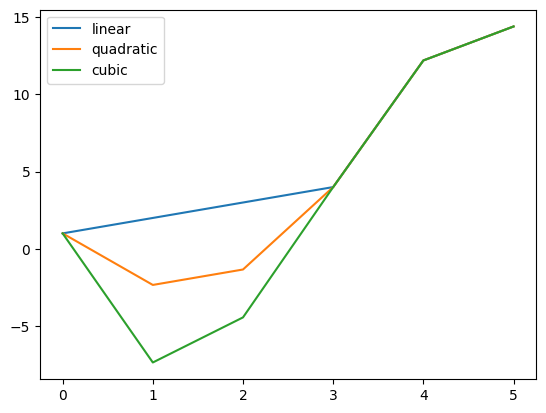

In [51]:
methods = ["linear", "quadratic", "cubic"]
df = pd.DataFrame({m: ser.interpolate(method=m) for m in methods})
df.plot()

### Discretization and Binning

Continuous data is often discretized or otherwise separated into “bins” for analysis.

In [52]:
#list of ages
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]

In [53]:
# divide ages into bins of 18 to 25, 26 to 35, 36 to 60, and finally 61 and older
bins = [18, 25, 35, 60, 100]
#use cut to divide ages according to defined bins
cats = pd.cut(ages, bins)
print('-'*30)
#The object pandas returns is a special Categorical object
cats

------------------------------


[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

In [54]:
# the distinct category names for the ages data is in the categories attribute
# a parenthesis means that the side is open
# the square bracket means it is closed (inclusive).
cats.categories

IntervalIndex([(18, 25], (25, 35], (35, 60], (60, 100]], dtype='interval[int64, right]')

In [55]:
# a lable of the ages data is in the codes attribute
cats.codes

array([0, 0, 0, 1, 0, 0, 2, 1, 3, 2, 2, 1], dtype=int8)

In [56]:
#the bin counts for the result of pandas.cut
pd.Series(cats).value_counts()

(18, 25]     5
(25, 35]     3
(35, 60]     3
(60, 100]    1
Name: count, dtype: int64

In [57]:
#We can also pass our own bin names by passing a list or array to the labels option
group_names = ['Youth', 'YoungAdult', 'MiddleAged', 'Senior']
pd.cut(ages, bins, labels=group_names)

['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'YoungAdult', 'Senior', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 12
Categories (4, object): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']

In [58]:
pd.Series(pd.cut(ages, bins, labels=group_names)).value_counts()

Youth         5
YoungAdult    3
MiddleAged    3
Senior        1
Name: count, dtype: int64

In [59]:
data = np.random.rand(20)
# Defines the number of equal-width bins to 4 in the range of the data
#The precision=2 option limits the decimal precision to two digits.
#Pick the edges of bins based on the min and max of data
pd.cut(data, 4, precision=2)

[(0.063, 0.3], (0.76, 0.99], (0.53, 0.76], (0.063, 0.3], (0.76, 0.99], ..., (0.063, 0.3], (0.76, 0.99], (0.53, 0.76], (0.53, 0.76], (0.53, 0.76]]
Length: 20
Categories (4, interval[float64, right]): [(0.063, 0.3] < (0.3, 0.53] < (0.53, 0.76] < (0.76, 0.99]]

In [60]:
# create data frame
serprice = pd.Series(np.random.randint(5000, 350000,size=500))
serprice[0]=5000
serprice[1]=450000
df = pd.DataFrame(serprice, columns=['price'])
df.head(5)

,price
0,5000
1,450000
2,198087
3,98737
4,6769


In [61]:
#define bins (3 bins)
bins = np.linspace(min(df['price']),max(df['price']),4)
#define group names
group_names=['Low','Medium','High']

In [62]:
pd.cut(df['price'],bins,labels=group_names)
#What happen with df[0]?

0         NaN
1        High
2      Medium
3         Low
4         Low
        ...  
495       Low
496       Low
497       Low
498    Medium
499    Medium
Name: price, Length: 500, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [63]:
# create a Categorical object
# include_lowest specifies whether the first interval should be left-inclusive or not.
pd.cut(df['price'],bins,labels=group_names, include_lowest=True)

0         Low
1        High
2      Medium
3         Low
4         Low
        ...  
495       Low
496       Low
497       Low
498    Medium
499    Medium
Name: price, Length: 500, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [64]:
# add a price_bins column
# include_lowest=True (include lowest (5000))
df['price_bins'] = pd.cut(df['price'],bins,labels=group_names, include_lowest=True)
df.head(5)

,price,price_bins
0,5000,Low
1,450000,High
2,198087,Medium
3,98737,Low
4,6769,Low


In [65]:
df['price_bins'].value_counts()

price_bins
Low       211
Medium    210
High       79
Name: count, dtype: int64

<Axes: >

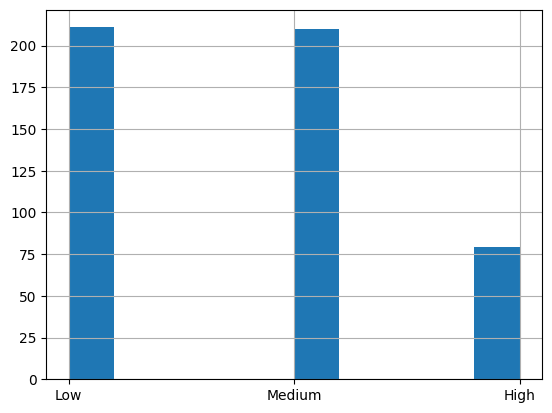

In [66]:
df['price_bins'].sort_values().hist()

<Axes: >

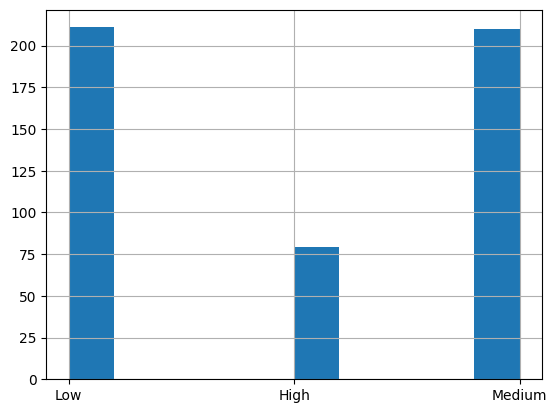

In [67]:
df['price_bins'].hist()

### Dummy variables in Pandas

In [68]:
#Create a DataFrame with categorical variables
fuel_list = ['gas','diesel']
car_list = list('ABCDEFGHIJ')
random_fuel=np.random.choice(fuel_list, 10)
df =pd.DataFrame({'Car':car_list,'Fuel':random_fuel})
df

,Car,Fuel
0,A,diesel
1,B,diesel
2,C,gas
3,D,diesel
4,E,diesel
5,F,diesel
6,G,gas
7,H,gas
8,I,diesel
9,J,diesel


In [69]:
#Convert categorical variable into dummy/indicator variables with get_dummies()
#Add dummy variables for each unique category
#Assign 0 or 1 in each category
df_dummy=pd.get_dummies(df['Fuel'], dtype='int')
df_dummy

,diesel,gas
0,1,0
1,1,0
2,0,1
3,1,0
4,1,0
5,1,0
6,0,1
7,0,1
8,1,0
9,1,0


In [70]:
type(df_dummy)

pandas.core.frame.DataFrame

In [71]:
#merge dataframe with join(). Row index must be equal
df_with_dummy = df.join(df_dummy)
df_with_dummy

,Car,Fuel,diesel,gas
0,A,diesel,1,0
1,B,diesel,1,0
2,C,gas,0,1
3,D,diesel,1,0
4,E,diesel,1,0
5,F,diesel,1,0
6,G,gas,0,1
7,H,gas,0,1
8,I,diesel,1,0
9,J,diesel,1,0


In [72]:
#merge dataframe with concat()
df_with_dummy2 = pd.concat([df, df_dummy], axis=1)
df_with_dummy2

,Car,Fuel,diesel,gas
0,A,diesel,1,0
1,B,diesel,1,0
2,C,gas,0,1
3,D,diesel,1,0
4,E,diesel,1,0
5,F,diesel,1,0
6,G,gas,0,1
7,H,gas,0,1
8,I,diesel,1,0
9,J,diesel,1,0


In [73]:
#combine get_dummies with a discretization function like cut
np.random.seed(12345)
values = np.random.rand(10)
print(values)
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
pd.get_dummies(pd.cut(values, bins), dtype='int')

[0.92961609 0.31637555 0.18391881 0.20456028 0.56772503 0.5955447
 0.96451452 0.6531771  0.74890664 0.65356987]


,"(0.0, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
0,0,0,0,0,1
1,0,1,0,0,0
2,1,0,0,0,0
3,0,1,0,0,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,0,0,0,1
7,0,0,0,1,0
8,0,0,0,1,0
9,0,0,0,1,0


In [74]:
print(values)

[0.92961609 0.31637555 0.18391881 0.20456028 0.56772503 0.5955447
 0.96451452 0.6531771  0.74890664 0.65356987]


### Combining and Merging Datasets

#### Database-Style DataFrame Joins

In [75]:
df1 = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'a', 'b'],
                    'data1': range(7)})
df2 = pd.DataFrame({'key': ['a', 'b', 'd'],
                    'data2': range(3)})

In [76]:
df1

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


In [77]:
df2

,key,data2
0,a,0
1,b,1
2,d,2


In [78]:
#merge uses the overlapping column names as the keys (inner)
pd.merge(df1, df2)

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [79]:
#It’s a good practice to specify the key explicitly
pd.merge(df1, df2, on='key', how = 'inner')

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [80]:
pd.merge(df1, df2, on = 'key', how='outer')

,key,data1,data2
0,a,2.0,0.0
1,a,4.0,0.0
2,a,5.0,0.0
3,b,0.0,1.0
4,b,1.0,1.0
5,b,6.0,1.0
6,c,3.0,NaN
7,d,NaN,2.0


In [81]:
#If the column names are different in each object, you can specify them separately
df3 = pd.DataFrame({'lkey': ['b', 'b', 'a', 'c', 'a', 'a', 'b'],
                    'data1': range(7)})
df4 = pd.DataFrame({'rkey': ['a', 'b', 'd'],
                    'data2': range(3)})
pd.merge(df3, df4, left_on='lkey', right_on='rkey', how = 'inner')

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,a,2,a,0
3,a,4,a,0
4,a,5,a,0
5,b,6,b,1


In [82]:
df3

,lkey,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


In [83]:
df4

,rkey,data2
0,a,0
1,b,1
2,d,2


#### Different join types with how argument
<br>

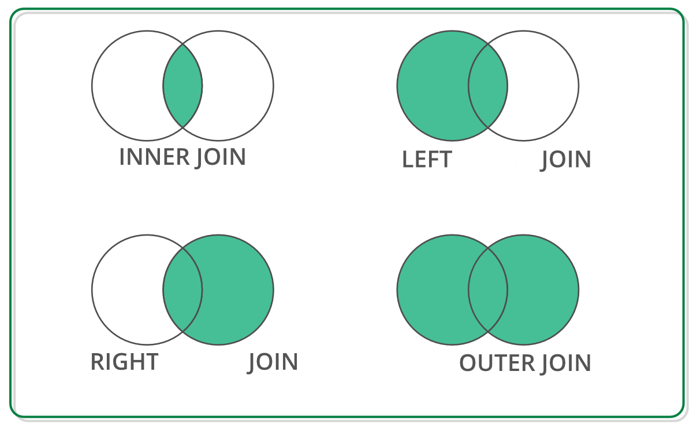

In [84]:
df1 = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'a', 'b'],
                    'data1': range(7)})
df2 = pd.DataFrame({'key': ['a', 'b', 'd'],
                    'data2': range(3)})

In [85]:
print(df1)
print("---------")
print(df2)

  key  data1
0   b      0
1   b      1
2   a      2
3   c      3
4   a      4
5   a      5
6   b      6
---------
  key  data2
0   a      0
1   b      1
2   d      2


In [86]:
# inner
print(sorted(df1['key'].unique()))
print(sorted(df2['key'].unique()))
pd.merge(df1, df2, how='inner')

['a', 'b', 'c']
['a', 'b', 'd']


,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [87]:
# outer
print(sorted(df1['key'].unique()))
print(sorted(df2['key'].unique()))
pd.merge(df1, df2, how='outer')

['a', 'b', 'c']
['a', 'b', 'd']


,key,data1,data2
0,a,2.0,0.0
1,a,4.0,0.0
2,a,5.0,0.0
3,b,0.0,1.0
4,b,1.0,1.0
5,b,6.0,1.0
6,c,3.0,NaN
7,d,NaN,2.0


In [88]:
# left
print(sorted(df1['key'].unique()))
print(sorted(df2['key'].unique()))
pd.merge(df1, df2, on='key', how='left')

['a', 'b', 'c']
['a', 'b', 'd']


,key,data1,data2
0,b,0,1.0
1,b,1,1.0
2,a,2,0.0
3,c,3,NaN
4,a,4,0.0
5,a,5,0.0
6,b,6,1.0


In [89]:
# right
print(sorted(df1['key'].unique()))
print(sorted(df2['key'].unique()))
pd.merge(df1, df2, on='key', how='right')

['a', 'b', 'c']
['a', 'b', 'd']


,key,data1,data2
0,a,2.0,0
1,a,4.0,0
2,a,5.0,0
3,b,0.0,1
4,b,1.0,1
5,b,6.0,1
6,d,NaN,2


In [90]:
import pandas as pd
df1 = pd.DataFrame([['a', 1],['b', 2]], columns = ['letter','number'])
df3 = pd.DataFrame([['c', 3,'cat'],['d', 4, 'dog']], columns = ['letter','number', 'animal'])
df4 = pd.DataFrame([['c', 3,'cat'],['d', 4, 'dog'], ['e', 5, 'bird']], columns = ['letter','number', 'animal'])

In [91]:
print(df1)
print(df3)
print(df4)

  letter  number
0      a       1
1      b       2
  letter  number animal
0      c       3    cat
1      d       4    dog
  letter  number animal
0      c       3    cat
1      d       4    dog
2      e       5   bird


In [92]:
pd.concat([df1, df4], axis = 1)

,letter,number,letter,number,animal
0,a,1.0,c,3,cat
1,b,2.0,d,4,dog
2,NaN,NaN,e,5,bird


In [93]:
df1 = pd.DataFrame({'lkey':['b','b','a','c','a','a','b'], 'data1':range(7)})
df2 = pd.DataFrame({'rkey':['a', 'b', 'd'], 'data2':range(3)})
pd.merge(df1, df2, left_on = 'lkey', right_on = 'rkey', how = 'outer')

,lkey,data1,rkey,data2
0,a,2.0,a,0.0
1,a,4.0,a,0.0
2,a,5.0,a,0.0
3,b,0.0,b,1.0
4,b,1.0,b,1.0
5,b,6.0,b,1.0
6,c,3.0,NaN,NaN
7,NaN,NaN,d,2.0


In [94]:
df1

,lkey,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


In [95]:
df2

,rkey,data2
0,a,0
1,b,1
2,d,2


#### Concatenating Along an Axis

The data structures like series and dataframe, having labeled axes allows us to do concatenation.

In [96]:
ser1 = pd.Series(np.random.rand(4), index=[1,2,3,4])
ser2 = pd.Series(np.random.rand(4), index=[5,6,7,8])
print(ser1)
print(ser2)

1    0.747715
2    0.961307
3    0.008388
4    0.106444
dtype: float64
5    0.298704
6    0.656411
7    0.809813
8    0.872176
dtype: float64


In [97]:
#By default, the concat() function works on axis = 0
pd.concat([ser1,ser2])

1    0.747715
2    0.961307
3    0.008388
4    0.106444
5    0.298704
6    0.656411
7    0.809813
8    0.872176
dtype: float64

In [98]:
#If you set the axis = 1, then the result will be a dataframe
pd.concat([ser1,ser2],axis=1)

,0,1
1,0.747715,NaN
2,0.961307,NaN
3,0.008388,NaN
4,0.106444,NaN
5,NaN,0.298704
6,NaN,0.656411
7,NaN,0.809813
8,NaN,0.872176


In [99]:
ser11 = pd.Series(np.random.rand(4), index=[1,2,3,4])
ser21 = pd.Series(np.random.rand(8), index=[1,2,3,4,5,6,7,8])
pd.concat([ser11, ser21], axis=1)
#What will happen?

,0,1
1,0.964648,0.467599
2,0.723685,0.325585
3,0.642475,0.439645
4,0.717454,0.729689
5,NaN,0.994015
6,NaN,0.676874
7,NaN,0.790823
8,NaN,0.170914


In [100]:
pd.concat([ser1,ser2], keys=[1,2])

1  1    0.747715
   2    0.961307
   3    0.008388
   4    0.106444
2  5    0.298704
   6    0.656411
   7    0.809813
   8    0.872176
dtype: float64

In [101]:
#Apply concat() to the dataframe
df1 = pd.DataFrame([['a', 1], ['b', 2]],
                   columns=['letter', 'number'])
df3 = pd.DataFrame([['c', 3, 'cat'], ['d', 4, 'dog']],
                   columns=['letter', 'number', 'animal'])
print(df1)
print(df3)

  letter  number
0      a       1
1      b       2
  letter  number animal
0      c       3    cat
1      d       4    dog


In [102]:
#work on axis=0
pd.concat([df1, df3])

,letter,number,animal
0,a,1,NaN
1,b,2,NaN
0,c,3,cat
1,d,4,dog


In [103]:
#work on axis = 1 (match rows with same index)
pd.concat([df1,df3],axis=1)

,letter,number,letter,number,animal
0,a,1,c,3,cat
1,b,2,d,4,dog


In [104]:
#Apply concat() to the dataframe
df11 = pd.DataFrame([['a', 1], ['b', 2]],
                   columns=['letter', 'number'])
df31 = pd.DataFrame([['c', 3, 'cat'], ['d', 4, 'dog'], ['e', 5, 'bird']],
                   columns=['letter', 'number', 'animal'])
pd.concat([df11, df31],axis=0)

,letter,number,animal
0,a,1,NaN
1,b,2,NaN
0,c,3,cat
1,d,4,dog
2,e,5,bird


In [105]:
df11

,letter,number
0,a,1
1,b,2


In [106]:
df31

,letter,number,animal
0,c,3,cat
1,d,4,dog
2,e,5,bird


In [107]:
#Use the keys option to create a hierarchical index
#work on axis =0
pd.concat([df11, df31], keys=['df1','df3'])

letter  number animal
df1 0      a       1    NaN
    1      b       2    NaN
df3 0      c       3    cat
    1      d       4    dog
    2      e       5   bird

### Sample Data Wrangling Operations


In [108]:
import numpy as np
import pandas as pd

# Create sample sensor data
np.random.seed(42)

df = pd.DataFrame(
    np.random.randn(10, 3),
    columns=["sensor1", "sensor2", "sensor3"]
)

df

,sensor1,sensor2,sensor3
0,0.496714,-0.138264,0.647689
1,1.523030,-0.234153,-0.234137
2,1.579213,0.767435,-0.469474
3,0.542560,-0.463418,-0.465730
4,0.241962,-1.913280,-1.724918
5,-0.562288,-1.012831,0.314247
6,-0.908024,-1.412304,1.465649
7,-0.225776,0.067528,-1.424748
8,-0.544383,0.110923,-1.150994
9,0.375698,-0.600639,-0.291694


#### Select one column

In [109]:
df["sensor1"]

0    0.496714
1    1.523030
2    1.579213
3    0.542560
4    0.241962
5   -0.562288
6   -0.908024
7   -0.225776
8   -0.544383
9    0.375698
Name: sensor1, dtype: float64

#### Select multiple columns

In [110]:
df[["sensor1", "sensor3"]]

,sensor1,sensor3
0,0.496714,0.647689
1,1.523030,-0.234137
2,1.579213,-0.469474
3,0.542560,-0.465730
4,0.241962,-1.724918
5,-0.562288,0.314247
6,-0.908024,1.465649
7,-0.225776,-1.424748
8,-0.544383,-1.150994
9,0.375698,-0.291694


#### Filter rows

In [111]:
df["sensor2"] > 0
df[df["sensor2"] > 0]

,sensor1,sensor2,sensor3
2,1.579213,0.767435,-0.469474
7,-0.225776,0.067528,-1.424748
8,-0.544383,0.110923,-1.150994


#### Create/transform columns

In [112]:
df['sensor4'] = df['sensor3']**2
df

,sensor1,sensor2,sensor3,sensor4
0,0.496714,-0.138264,0.647689,0.419500
1,1.523030,-0.234153,-0.234137,0.054820
2,1.579213,0.767435,-0.469474,0.220406
3,0.542560,-0.463418,-0.465730,0.216904
4,0.241962,-1.913280,-1.724918,2.975342
5,-0.562288,-1.012831,0.314247,0.098751
6,-0.908024,-1.412304,1.465649,2.148126
7,-0.225776,0.067528,-1.424748,2.029907
8,-0.544383,0.110923,-1.150994,1.324786
9,0.375698,-0.600639,-0.291694,0.085085


#### Remove rows or columns

In [113]:
df.drop(index=[1, 2])

,sensor1,sensor2,sensor3,sensor4
0,0.496714,-0.138264,0.647689,0.419500
3,0.542560,-0.463418,-0.465730,0.216904
4,0.241962,-1.913280,-1.724918,2.975342
5,-0.562288,-1.012831,0.314247,0.098751
6,-0.908024,-1.412304,1.465649,2.148126
7,-0.225776,0.067528,-1.424748,2.029907
8,-0.544383,0.110923,-1.150994,1.324786
9,0.375698,-0.600639,-0.291694,0.085085


In [114]:
df.drop(columns=["sensor1"])

,sensor2,sensor3,sensor4
0,-0.138264,0.647689,0.419500
1,-0.234153,-0.234137,0.054820
2,0.767435,-0.469474,0.220406
3,-0.463418,-0.465730,0.216904
4,-1.913280,-1.724918,2.975342
5,-1.012831,0.314247,0.098751
6,-1.412304,1.465649,2.148126
7,0.067528,-1.424748,2.029907
8,0.110923,-1.150994,1.324786
9,-0.600639,-0.291694,0.085085


Question: Select sensor1 and sensor3 only for observations where sensor2 > 0 and sensor1 < 0.

### GroupBy and Aggregate (Split-Apply-Combine)
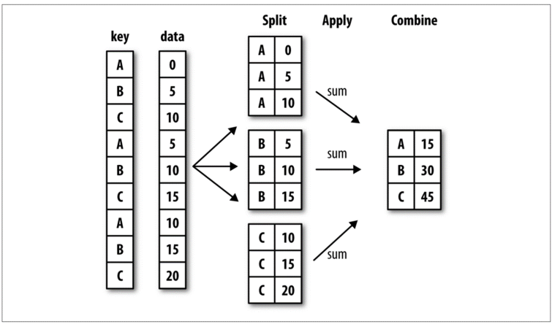


In [115]:
np.random.seed(12345)
df = pd.DataFrame({'key1' : ['a', 'a', 'b', 'b', 'a'],
                   'key2' : ['one', 'two', 'one', 'two', 'one'],
                   'data1' : np.random.randint(0,10,5),
                   'data2' : np.random.randint(0,10,5)})
df

,key1,key2,data1,data2
0,a,one,2,5
1,a,two,5,2
2,b,one,1,1
3,b,two,4,6
4,a,one,9,1


In [116]:
group1 = df.groupby('key1')
group2 = df.groupby(['key1','key2'])
group2.sum()


data1  data2
key1 key2              
a    one      11      6
     two       5      2
b    one       1      1
     two       4      6

In [117]:
group1 = df.groupby('key1')[['data1','data2']]
group1.cumsum()

,data1,data2
0,2,5
1,7,7
2,1,1
3,5,7
4,16,8


In [118]:
#split data1 into group by key1
grouped = df['data1'].groupby(df['key1'])
grouped

In [119]:
grouped.groups

{'a': [0, 1, 4], 'b': [2, 3]}

In [120]:
# apply aggreation function on each group and combine to a single series
grouped.mean()

key1
a    5.333333
b    2.500000
Name: data1, dtype: float64

In [121]:
#df.groupby('key1').mean()
group1 = df.groupby('key1')
group1.sum()

,key2,data1,data2
key1,,,
a,onetwoone,16,8
b,onetwo,5,7


In [122]:
# Grouping the data using two keys, and the resulting Series now has
# a hierarchical index consisting of the unique pairs of keys observed
means = df['data1'].groupby([df['key1'], df['key2']]).mean()
means

key1  key2
a     one     5.5
      two     5.0
b     one     1.0
      two     4.0
Name: data1, dtype: float64

In [123]:
df.groupby(['key1', 'key2']).mean()

data1  data2
key1 key2              
a    one     5.5    3.0
     two     5.0    2.0
b    one     1.0    1.0
     two     4.0    6.0

In [124]:
df.groupby(['key1', 'key2']).size()

key1  key2
a     one     2
      two     1
b     one     1
      two     1
dtype: int64

#### According to the Excel file [link text](https://docs.google.com/spreadsheets/d/1nCvYudELZ2dHalcN1cgyBETVLIlsJH3Y/edit?usp=sharing&ouid=109490781053394626832&rtpof=true&sd=true), answer the following problems using NumPy and Pandas. Show all your code and answers.





In [125]:
#Q1. Show emails of everyone (Fred, Aleksander, Greta and Taylor).



In [126]:
#Q2. Calculate the mean salary of both male (M) and female (F).



### String

In [127]:
data = {'key':['k0','k1','k2','k3'],
        'city':['city_0','city_1','city_2','city_3'],
        'hire_date':['h0','h1','h2','h3']}
df = pd.DataFrame(data)
df['city'].str.split('_')

0    [city, 0]
1    [city, 1]
2    [city, 2]
3    [city, 3]
Name: city, dtype: object

In [128]:
df

,key,city,hire_date
0,k0,city_0,h0
1,k1,city_1,h1
2,k2,city_2,h2
3,k3,city_3,h3


In [131]:
#replace '_' with '##'
# How to do it with Python string?


In [132]:
#Use object as a default type of string
pd.Series(["a", "b", "c"])

0    a
1    b
2    c
dtype: object

In [133]:
#To explicitly request string dtype, specify the dtype
x = pd.Series(["a1", "b2", "c3"], dtype="string")
x

0    a1
1    b2
2    c3
dtype: string

In [134]:
x.str.extract('([ab])')

,0
0,a
1,b
2,<NA>


In [135]:
x.str.extract(r'(\d)')

,0
0,1
1,2
2,3


### Date/Time

#### 1. Creating datetime objects

In [136]:
# From a single string
print(pd.to_datetime("2025-09-01"))

# From a list
print(pd.to_datetime(["2025-01-01", "2025-09-01"]))

2025-09-01 00:00:00
DatetimeIndex(['2025-01-01', '2025-09-01'], dtype='datetime64[ns]', freq=None)


#### 2. Date/time column in a DataFrame

In [137]:
df = pd.DataFrame({
    "event": ["start", "end"],
    "date": ["2025-01-01", "2025-09-01"]
})
df.dtypes

event    object
date     object
dtype: object

In [138]:
df["date"] = pd.to_datetime(df["date"])
print(df.dtypes)
#What's the data type of 'date'?

event            object
date     datetime64[ns]
dtype: object


#### 3. Accessing datetime components

In [139]:
df = pd.DataFrame({
    "event": ["start", "end"], 
    "date": ["2025-01-01", "2025-09-01"]
})
df = df.astype({"event":"object", "date": "datetime64[ns]"})

In [140]:
#Use .dt accessor for vectorized datetime operations.

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.day_name()
print(df)

   event       date  year  month    weekday
0  start 2025-01-01  2025      1  Wednesday
1    end 2025-09-01  2025      9     Monday


#### 4. Arithmetic with dates

In [141]:
df["date_plus_7d"] = df["date"] + pd.Timedelta(days=7)
df["date_diff"] = df["date"] - pd.Timestamp("2025-01-01")
print(df)

   event       date  year  month    weekday date_plus_7d date_diff
0  start 2025-01-01  2025      1  Wednesday   2025-01-08    0 days
1    end 2025-09-01  2025      9     Monday   2025-09-08  243 days


#### 5. Date ranges

In [142]:
#Pandas can easily generate ranges of dates using pd.date_range()

drange = pd.date_range(start="2025-01-01", end="2025-01-10", freq="2D")
print(drange)

DatetimeIndex(['2025-01-01', '2025-01-03', '2025-01-05', '2025-01-07',
               '2025-01-09'],
              dtype='datetime64[ns]', freq='2D')


In [143]:
#Convert to pandas series
pd.Series(drange)

0   2025-01-01
1   2025-01-03
2   2025-01-05
3   2025-01-07
4   2025-01-09
dtype: datetime64[ns]

#### 6. Resampling (time series)

In [144]:
#If your index is datetime, you can resample (downsample/upsample) easily.
ts = pd.Series(
    [10, 20, 30, 40],
    index=pd.date_range("2025-01-01", periods=4, freq="D")
)
print(ts)

2025-01-01    10
2025-01-02    20
2025-01-03    30
2025-01-04    40
Freq: D, dtype: int64


In [145]:
print(ts.resample("2D").mean())

2025-01-01    15.0
2025-01-03    35.0
Freq: 2D, dtype: float64


#### 7. Time zones

In [146]:
dt = pd.to_datetime("2025-09-01 12:00:00")
dt_utc = dt.tz_localize("UTC")
dt_bkk = dt_utc.tz_convert("Asia/Bangkok")
print(dt_utc, "→", dt_bkk)

2025-09-01 12:00:00+00:00 → 2025-09-01 19:00:00+07:00


#### 8. Time Peroid

In [147]:
t_period = pd.Period("2025-09", freq="M")
t_period

Period('2025-09', 'M')

In [148]:
print(t_period.start_time, t_period.end_time)

2025-09-01 00:00:00 2025-09-30 23:59:59.999999999


In [149]:
#check that the instant time is within the time period
t_instant = pd.to_datetime("2025-09-01 12:00:00")
t_instant


Timestamp('2025-09-01 12:00:00')

#### 9. pd.to_datetime()

In [150]:
import pandas as pd

In [151]:
df = pd.DataFrame({
    "date": ["2026-09-01", "2026-09-02", "invalid"]
})

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df

,date
0,2026-09-01
1,2026-09-02
2,NaT


In [152]:
df["date"].dt.year
df["date"].dt.month
df["date"].dt.day

0    1.0
1    2.0
2    NaN
Name: date, dtype: float64